In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed
from source.make_train_test import make_teams_target, make_training_data


In [2]:
men_reg = pd.read_csv('data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv')
men_reg = process_details(men_reg)
men_reg = full_stats(men_reg)

men_reg.head()

,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,...,FGM_perc,FGM2_perc,FGM3_perc,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc
0,2010,3102,10.250000,0.707348,-0.743394,-9.285714,0.000000,0.642857,-4.392857,19.535714,...,0.360215,0.393064,0.284444,0.678378,0.464552,0.439484,0.570219,0.403226,0.547182,0.0
1,2010,3103,13.433333,0.771416,0.105735,1.733333,0.200000,2.400000,-1.400000,23.566667,...,0.402292,0.427570,0.315508,0.705782,0.395802,0.487030,0.471385,0.437877,0.425409,1.0
2,2010,3104,13.103448,0.713136,-0.018906,0.586207,0.172414,2.931034,-0.655172,25.931034,...,0.398112,0.430131,0.295082,0.616016,0.470014,0.461474,0.479924,0.433093,0.439794,0.0
3,2010,3105,9.740741,0.396488,-0.306001,-3.740741,0.259259,5.148148,0.740741,23.370370,...,0.400583,0.423146,0.307116,0.698630,0.521818,0.493659,0.476970,0.430444,0.428525,0.0
4,2010,3106,11.482759,0.628757,0.101945,1.965517,0.172414,4.482759,0.517241,24.758621,...,0.348081,0.362986,0.280576,0.647989,0.377570,0.433747,0.459914,0.373455,0.389796,1.0


In [3]:
men_reg = add_seed('data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv', men_reg)

In [6]:
men_target_data = pd.read_csv('data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv')
men_target_data = make_teams_target(men_target_data, "women")

In [7]:
men_training = make_training_data(men_reg, men_target_data)
men_training  = men_training[men_training.DayNum >= 136]  # remove pre tourney 

men_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,delta_FT_perc,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge
0,2010,138,3124,3201,1,14,0,0,2010_3124_3201,14.687500,...,0.017260,0.003363,0.011115,-0.058852,-0.006363,-0.059721,-1.0,-9.0,16.018610,22.390435
1,2010,138,3173,3395,1,1,0,0,2010_3173_3395,14.461538,...,-0.048387,0.045179,-0.008639,-0.000009,-0.005021,0.000092,-0.5,-1.0,15.342736,16.577034
2,2010,138,3181,3214,1,35,1,-1,2010_3181_3214,14.250000,...,-0.052773,-0.008327,0.033840,-0.015262,0.046713,-0.008046,-1.0,-13.0,18.346672,14.704430
3,2010,138,3199,3256,1,14,1,-1,2010_3199_3256,15.333333,...,0.028984,-0.046366,0.031177,0.000046,0.031522,-0.007994,-0.5,-11.0,16.584229,16.482703
4,2010,138,3207,3265,1,20,0,0,2010_3207_3265,15.866667,...,-0.081570,-0.048658,-0.040099,0.068819,-0.031317,0.056245,0.0,-7.0,11.817582,17.702842


# Winning target

In [8]:
target = "target"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,target
0,2010,138,3124,3201,0,0,14.687500,0.960990,0.234960,5.187500,...,0.003363,0.011115,-0.058852,-0.006363,-0.059721,-1.0,-9.0,16.018610,22.390435,1
1,2010,138,3173,3395,0,0,14.461538,0.914260,0.217115,2.807692,...,0.045179,-0.008639,-0.000009,-0.005021,0.000092,-0.5,-1.0,15.342736,16.577034,1
2,2010,138,3181,3214,1,-1,14.250000,0.852434,0.301444,2.875000,...,-0.008327,0.033840,-0.015262,0.046713,-0.008046,-1.0,-13.0,18.346672,14.704430,1
3,2010,138,3199,3256,1,-1,15.333333,0.856383,0.163885,3.100000,...,-0.046366,0.031177,0.000046,0.031522,-0.007994,-0.5,-11.0,16.584229,16.482703,1
4,2010,138,3207,3265,0,0,15.866667,1.052721,0.453468,2.600000,...,-0.048658,-0.040099,0.068819,-0.031317,0.056245,0.0,-7.0,11.817582,17.702842,1


In [9]:
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

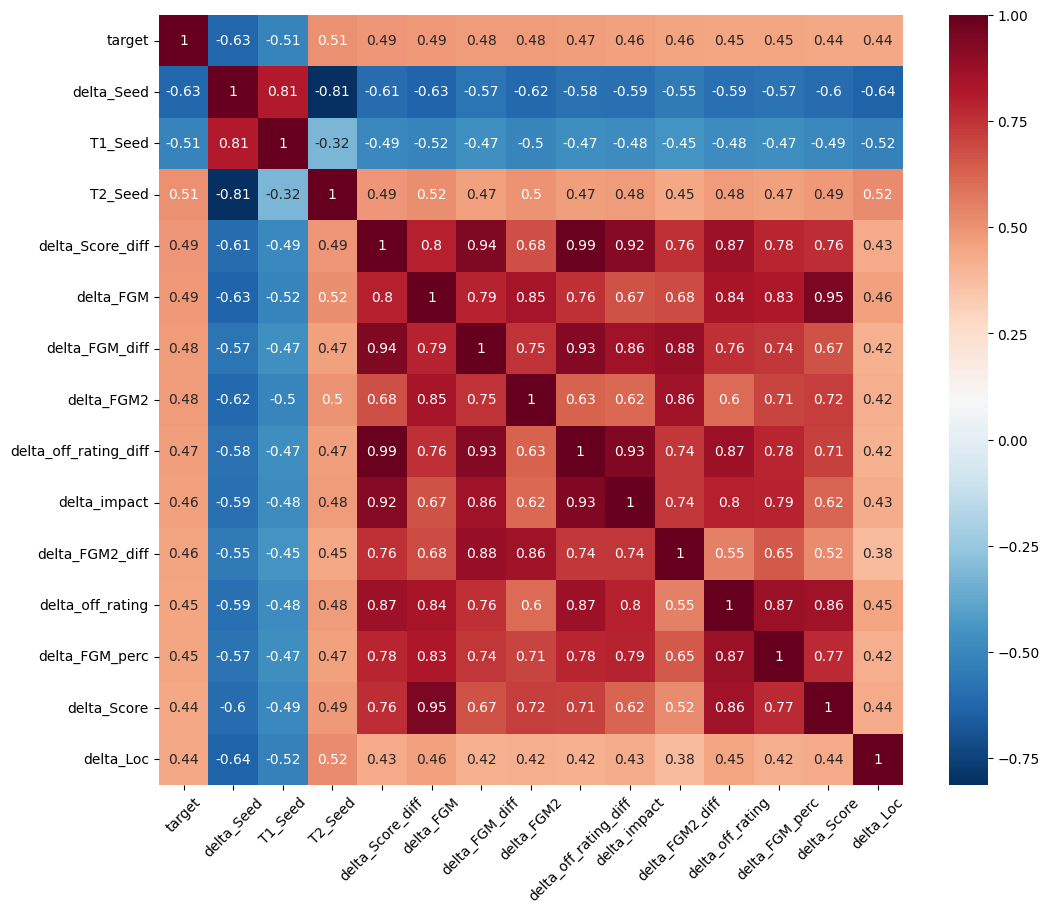

In [10]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

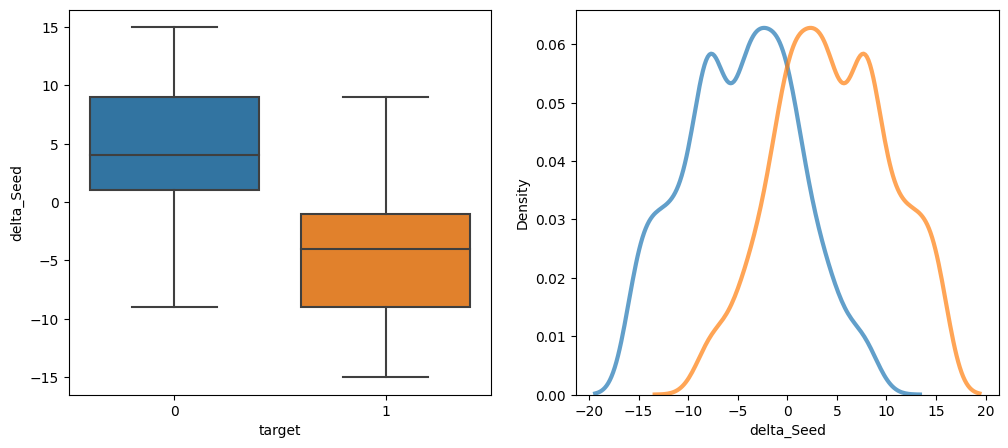

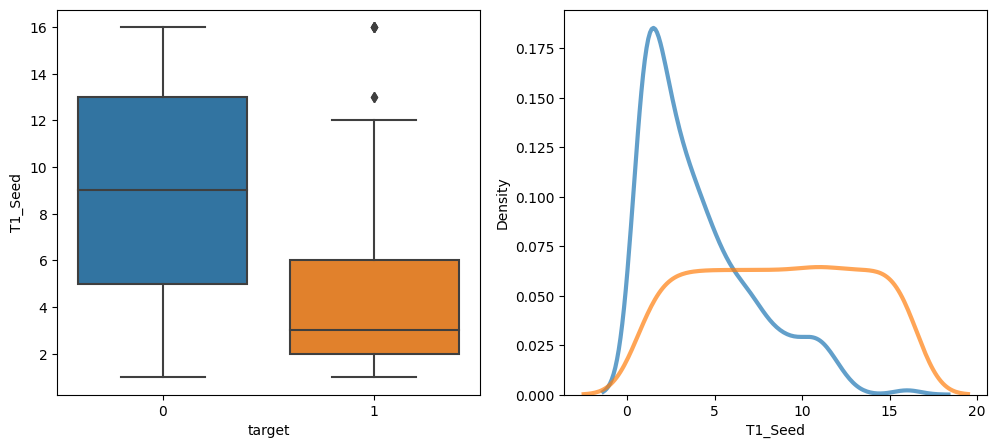

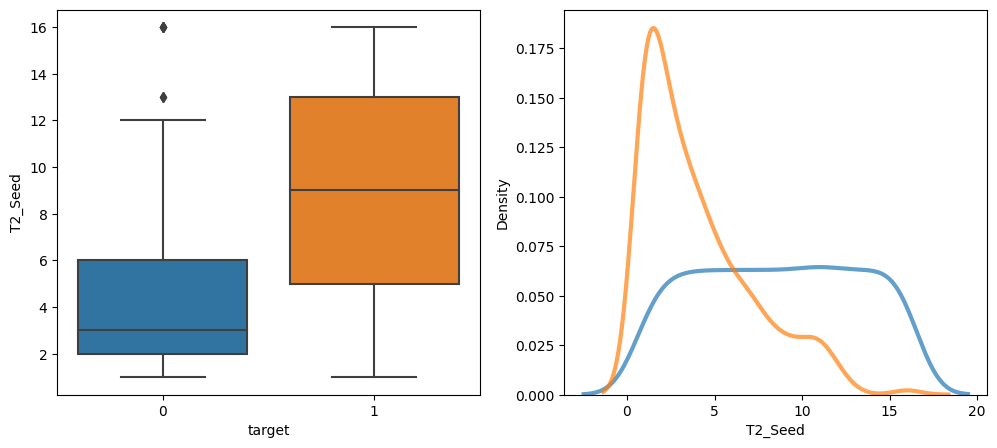

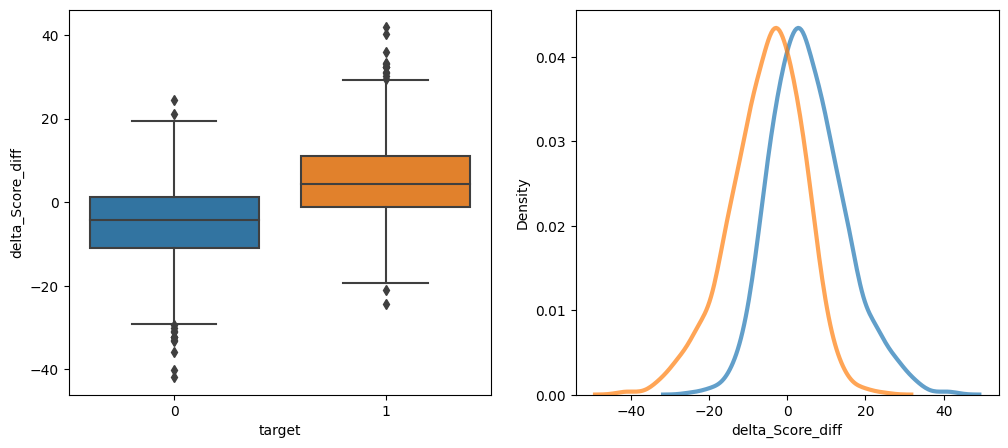

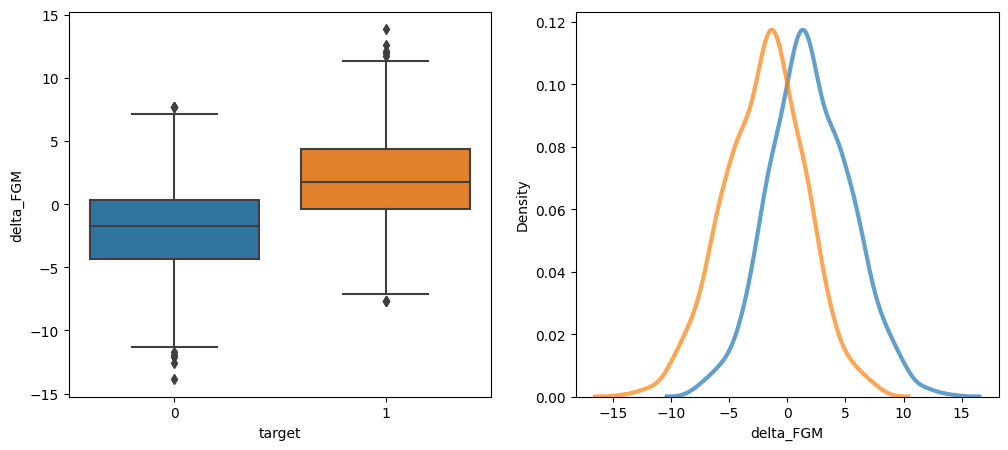

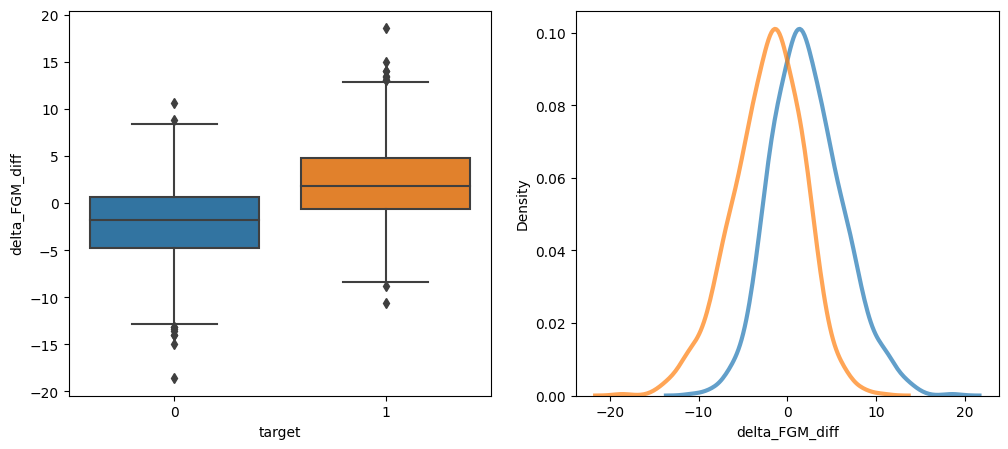

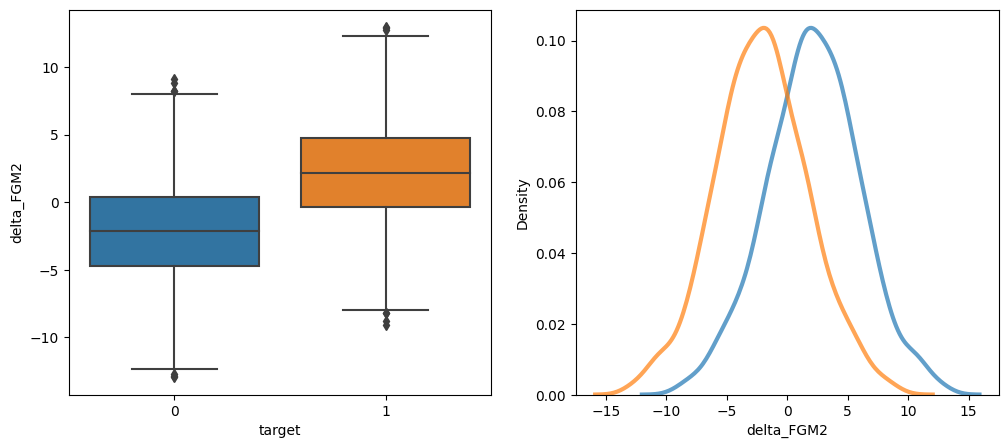

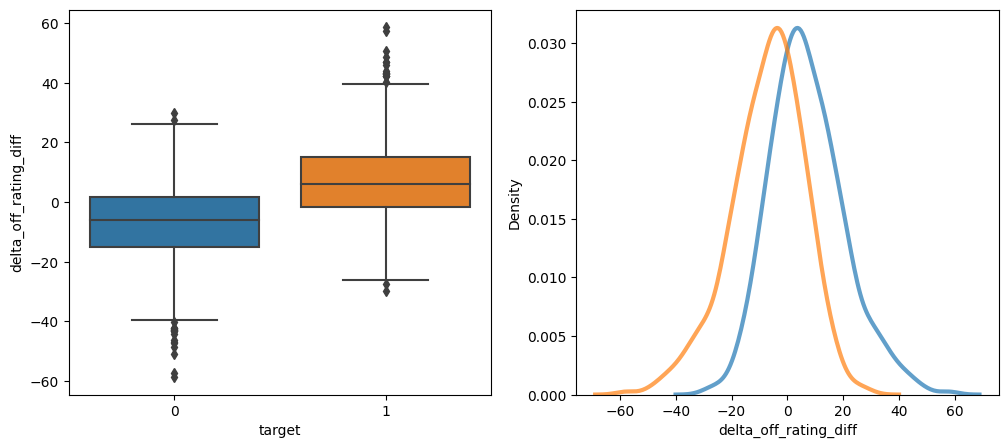

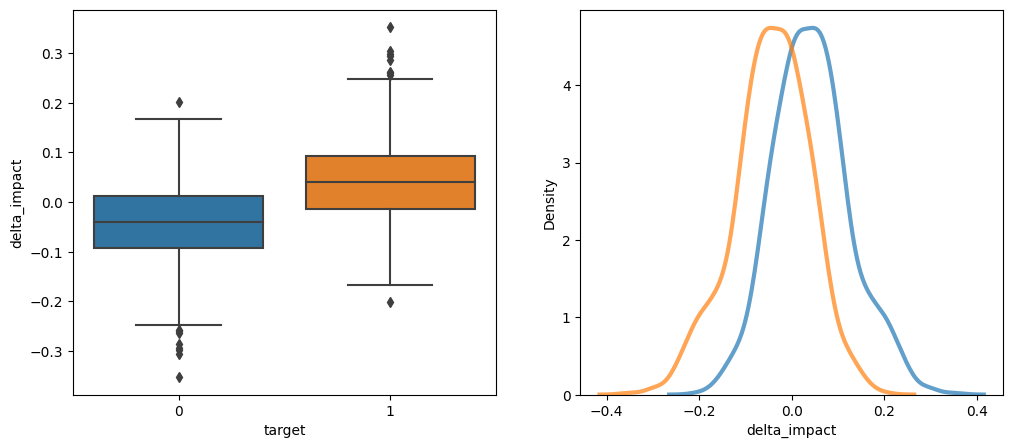

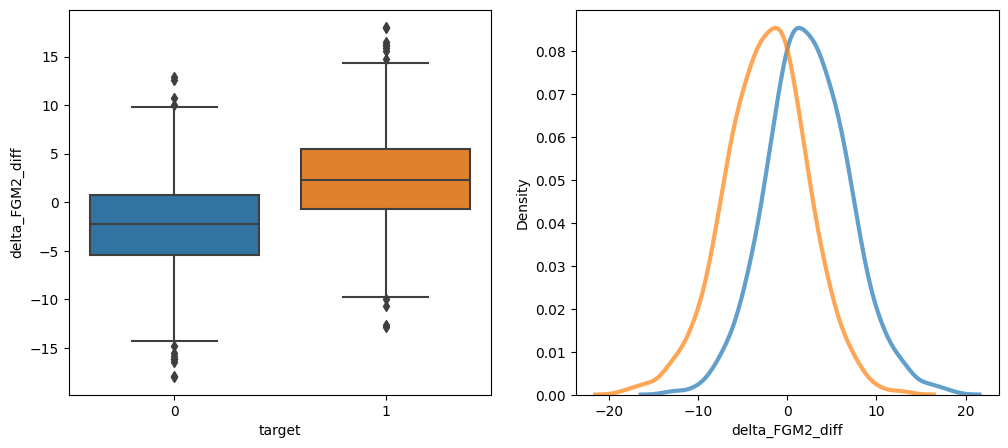

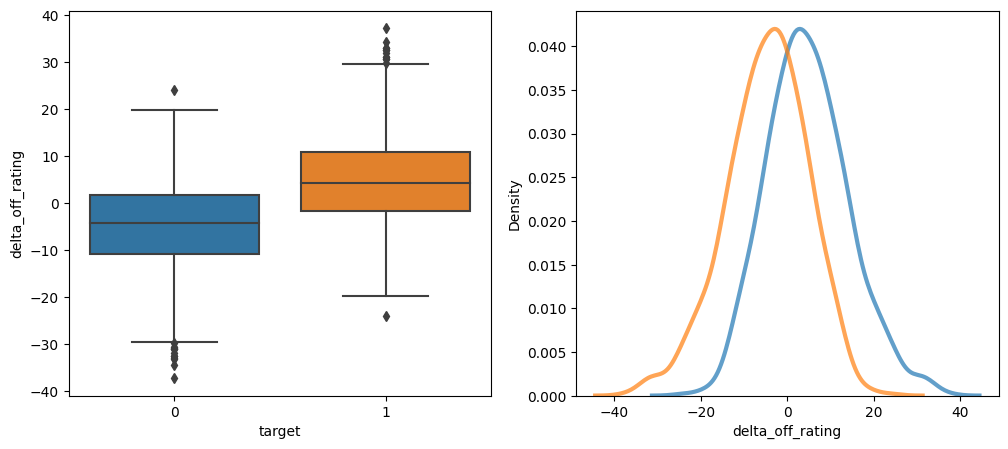

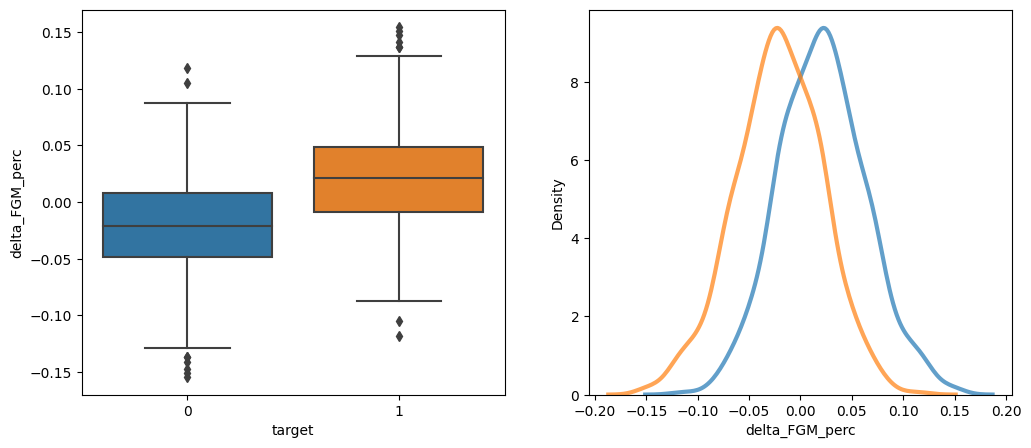

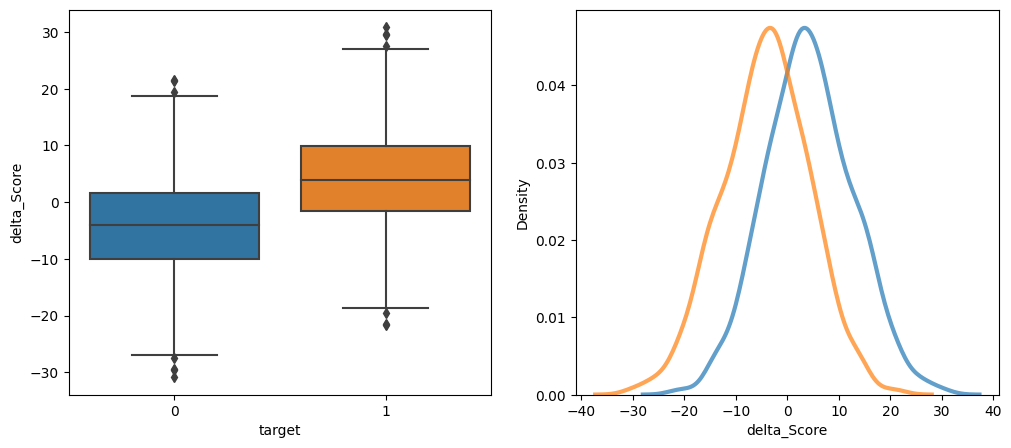

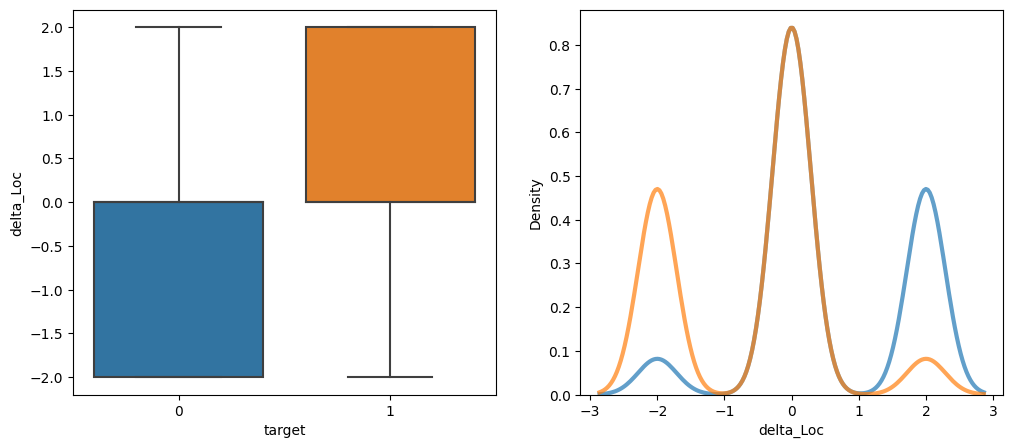

In [11]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [12]:
target = "target_points"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,target_points
0,2010,138,3124,3201,0,0,14.687500,0.960990,0.234960,5.187500,...,0.003363,0.011115,-0.058852,-0.006363,-0.059721,-1.0,-9.0,16.018610,22.390435,14
1,2010,138,3173,3395,0,0,14.461538,0.914260,0.217115,2.807692,...,0.045179,-0.008639,-0.000009,-0.005021,0.000092,-0.5,-1.0,15.342736,16.577034,1
2,2010,138,3181,3214,1,-1,14.250000,0.852434,0.301444,2.875000,...,-0.008327,0.033840,-0.015262,0.046713,-0.008046,-1.0,-13.0,18.346672,14.704430,35
3,2010,138,3199,3256,1,-1,15.333333,0.856383,0.163885,3.100000,...,-0.046366,0.031177,0.000046,0.031522,-0.007994,-0.5,-11.0,16.584229,16.482703,14
4,2010,138,3207,3265,0,0,15.866667,1.052721,0.453468,2.600000,...,-0.048658,-0.040099,0.068819,-0.031317,0.056245,0.0,-7.0,11.817582,17.702842,20


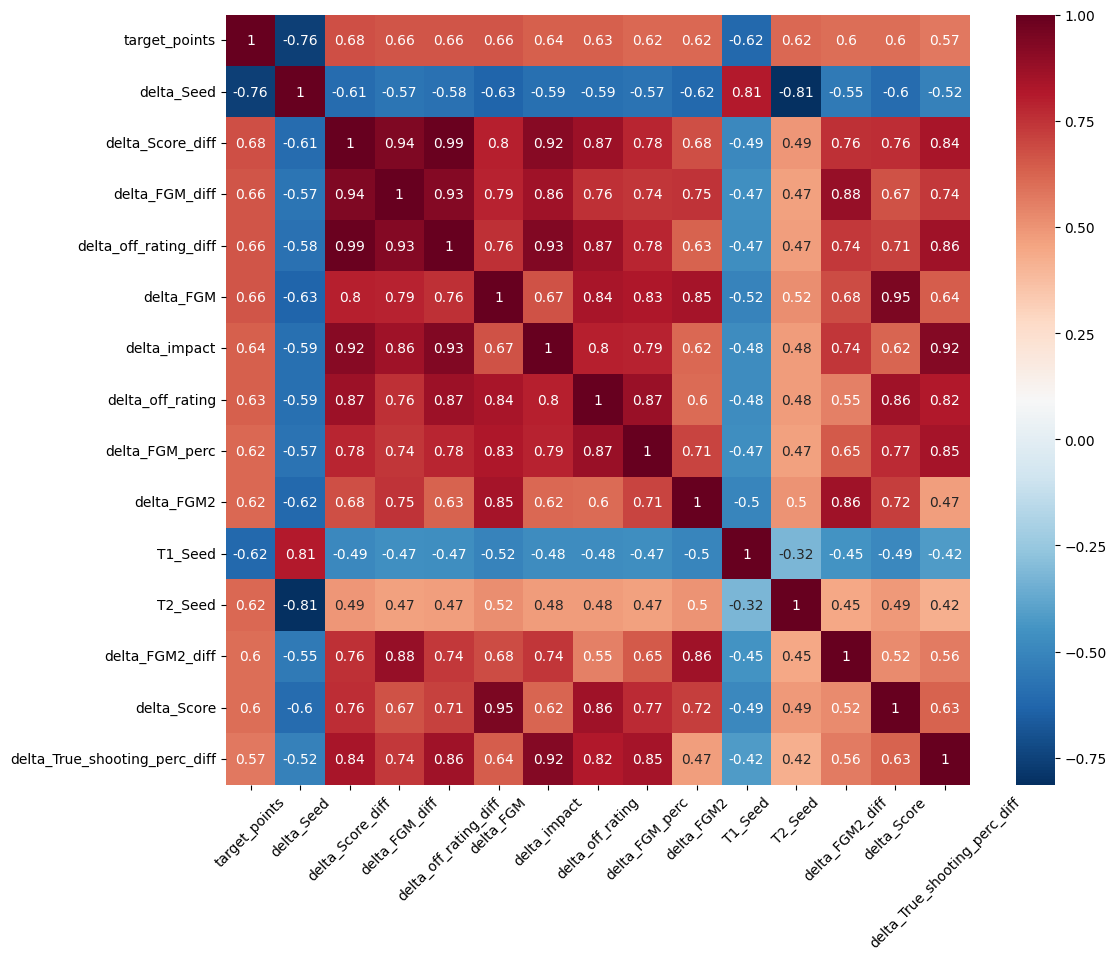

In [13]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

                               delta_Seed  delta_Score_diff  delta_FGM_diff  \
delta_Seed                       1.000000         -0.605744       -0.572135   
delta_Score_diff                -0.605744          1.000000        0.940150   
delta_FGM_diff                  -0.572135          0.940150        1.000000   
delta_off_rating_diff           -0.579630          0.992795        0.927261   
delta_FGM                       -0.633984          0.800544        0.792125   
delta_impact                    -0.587147          0.917661        0.858634   
delta_off_rating                -0.587156          0.866760        0.755569   
delta_FGM_perc                  -0.573303          0.784660        0.742688   
delta_FGM2                      -0.619992          0.675439        0.745826   
T1_Seed                          0.813143         -0.492556       -0.465228   
T2_Seed                         -0.813143          0.492556        0.465228   
delta_FGM2_diff                 -0.550278          0

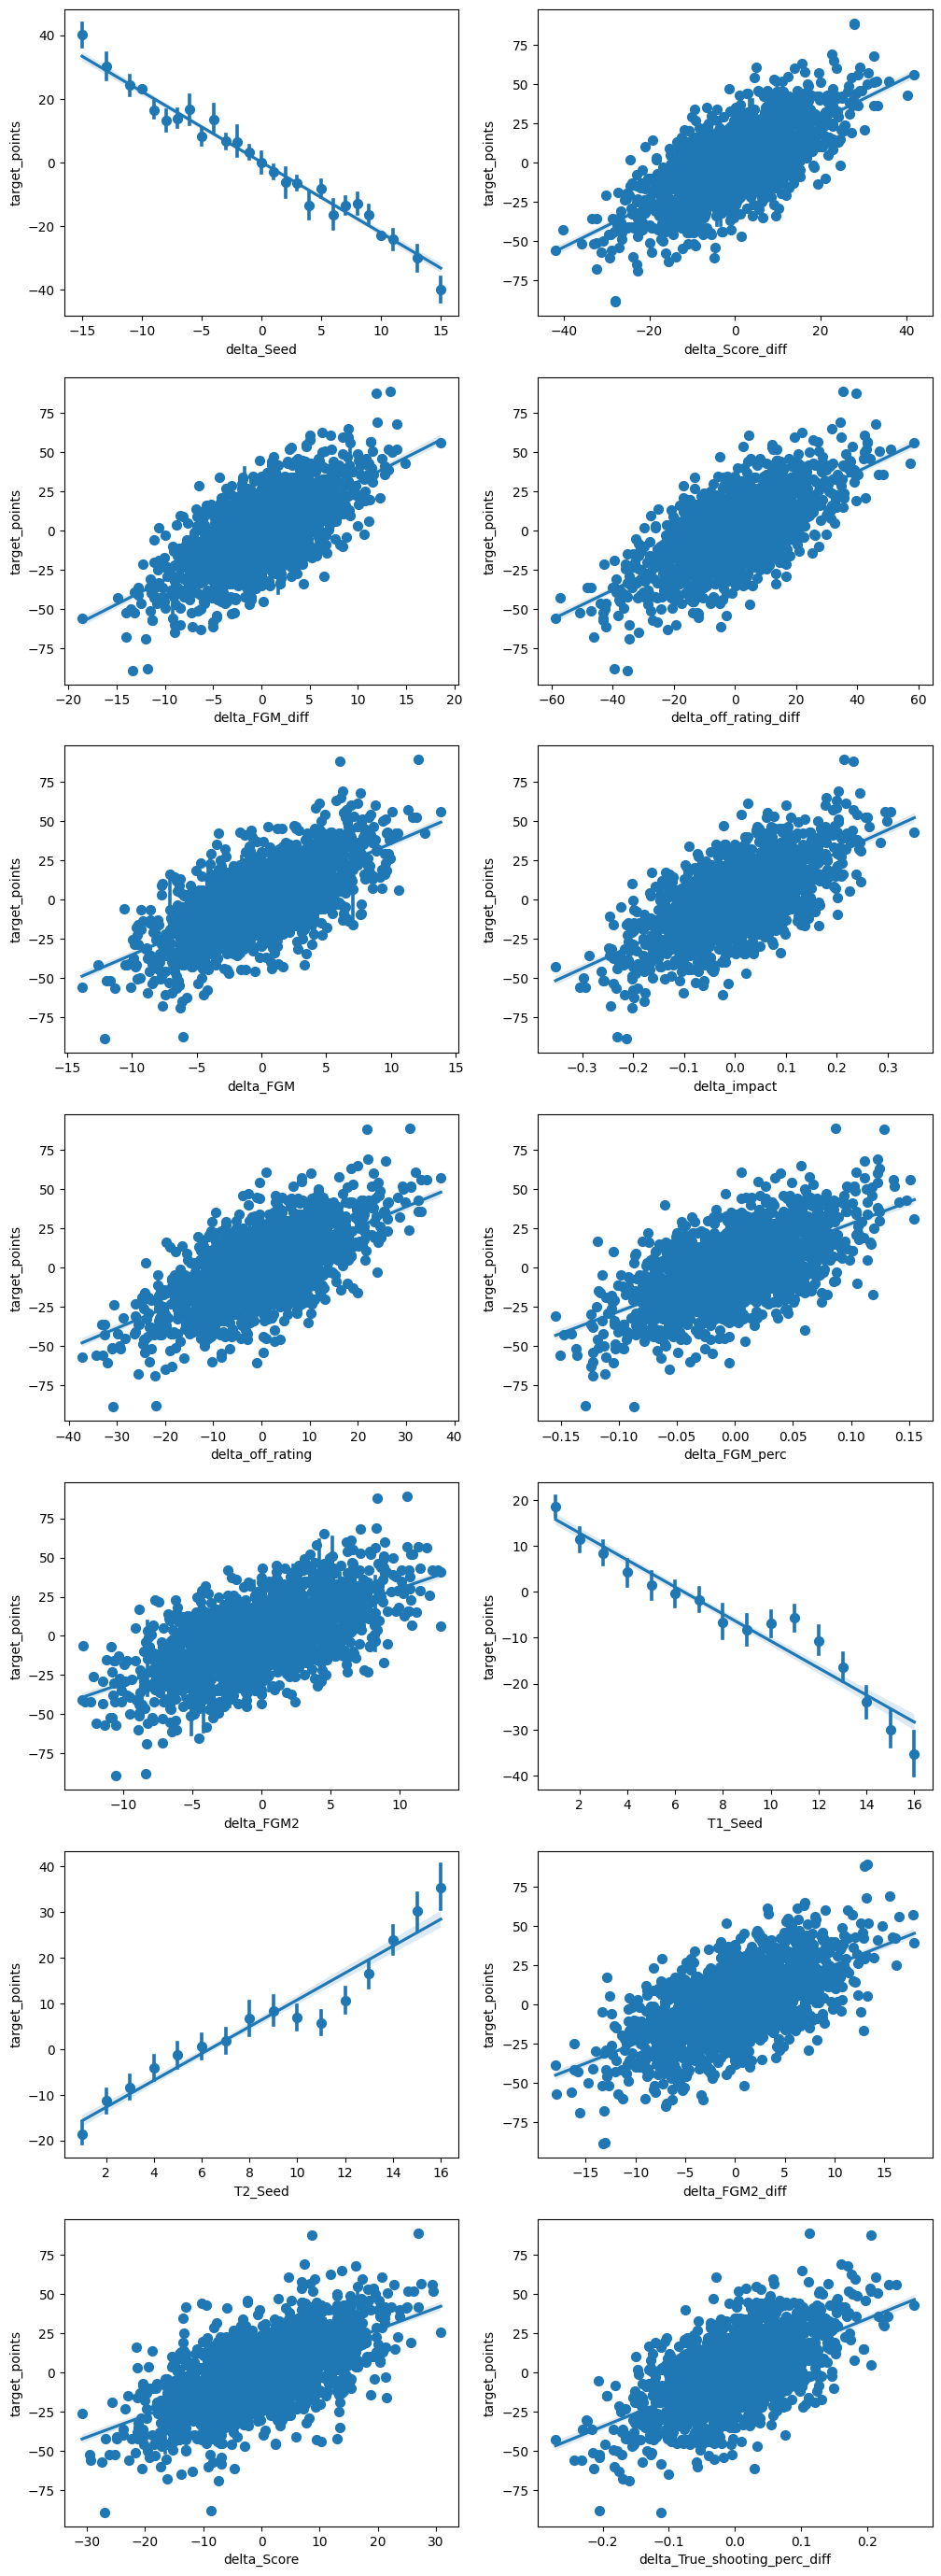

In [14]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)